# Deep Reinforcement Learning: DDPG for Pendulum-v1

This notebook develops a **Deep Deterministic Policy Gradient (DDPG)** agent for `Pendulum-v1`.


The version keeps the important architecture and hyperparameters while implementing the actor, critic, replay buffer, Ornstein-Uhlenbeck exploration, target networks, soft updates, training loop, evaluation, and visualization directly in TensorFlow and Gymnasium.

The notebook covers:

- the Pendulum state and continuous action,
- normalized actor action versus physical torque,
- native Pendulum reward,
- why DDPG is suitable,
- actor and critic architectures,
- experience replay,
- target actor and target critic,
- soft target updates,
- Ornstein-Uhlenbeck exploration noise,
- critic and actor objectives,
- a complete numerical DDPG calculation,
- 120-episode training,
- periodic deterministic evaluation,
- reward and learning diagnostics,
- angle/velocity/torque analysis,
- learned policy visualization,
- save/load,
- and MP4 evaluation video.

## 1. Pendulum control problem

The objective is to swing the pendulum upward and keep it near the upright position.

The Gymnasium observation is

$$
\boxed{
S_t=
[\cos\theta_t,\ \sin\theta_t,\ \dot{\theta}_t]
}
$$

where:

| Index | State variable | Meaning |
|---:|---|---|
| 0 | $\cos\theta_t$ | cosine of pendulum angle |
| 1 | $\sin\theta_t$ | sine of pendulum angle |
| 2 | $\dot{\theta}_t$ | angular velocity |

The raw angle is therefore recovered with

$$
\boxed{
\theta_t=
\operatorname{atan2}
(\sin\theta_t,\cos\theta_t)
}
$$

so that

$$
-\pi\leq\theta_t\leq\pi.
$$

The upright position corresponds to

$$
\boxed{\theta=0}.
$$

## 2. Continuous action and your wrapper

The native environment expects torque in

$$
\boxed{
-2\leq u_t\leq2
}
$$

but your actor uses a `tanh` output:

$$
\boxed{
a_t=\mu(S_t;\theta^\mu)\in[-1,1].
}
$$

Your wrapper then performs:

```python
action = np.clip(action, -1, 1) * 2
```

Therefore,

$$
\boxed{
u_t=2a_t
}
$$

where:

- $a_t$ is the normalized actor action used by the DDPG agent,
- $u_t$ is the physical torque sent to Gymnasium.

This notebook preserves that design.

The critic also receives the **normalized action** $a_t\in[-1,1]$, while the environment wrapper converts it to torque before calling `env.step()`.

## 3. Native Pendulum reward

The environment reward is

$$
\boxed{
R_{t+1}
=
-\left(
\theta_t^2
+
0.1\dot{\theta}_t^2
+
0.001u_t^2
\right)
}
$$

where:

- $\theta_t$ is the normalized angle in $[-\pi,\pi]$,
- $\dot{\theta}_t$ is angular velocity,
- $u_t$ is the applied torque in $[-2,2]$.

The best possible instantaneous reward is

$$
\boxed{0}
$$

when the pendulum is upright, motionless, and requires no torque.

Therefore, **less-negative reward is better**.

## 4. Reward example

Suppose

$$
\theta_t=0.20\text{ rad},
$$

$$
\dot{\theta}_t=0.50\text{ rad/s},
$$

and the actual applied torque is

$$
u_t=1.0.
$$

Then

$$
R_{t+1}
=
-\left[
(0.20)^2
+
0.1(0.50)^2
+
0.001(1.0)^2
\right]
$$

$$
=
-\left[
0.040
+
0.025
+
0.001
\right]
$$

$$
\boxed{
R_{t+1}=-0.066.
}
$$

A smaller angle, smaller angular speed, and lower unnecessary torque all improve the reward.

## 5. Why DDPG instead of DQN?

DQN evaluates a finite collection of actions:

$$
Q(s,a_1),Q(s,a_2),\ldots,Q(s,a_m).
$$

Pendulum requires a continuous torque, so there are infinitely many possible actions.

DDPG learns two functions.

### Actor

$$
\boxed{
a_t=\mu(S_t;\theta^\mu)
}
$$

The actor directly generates a continuous normalized action.

### Critic

$$
\boxed{
Q(S_t,a_t;\theta^Q)
}
$$

The critic estimates the long-term return associated with the state-action pair.

The control flow is

$$
\boxed{
S_t
\rightarrow
\mu(S_t)
\rightarrow
a_t
\rightarrow
u_t=2a_t
\rightarrow
\text{environment}
}
$$

## 6. Actor network

The supplied actor architecture is retained:

$$
\boxed{
3\rightarrow256\rightarrow256\rightarrow1
}
$$

The hidden layers use ReLU.

The final layer uses `tanh`:

$$
\boxed{
a_t\in[-1,1].
}
$$

Its weights use the supplied small initialization:

$$
W\sim U(-0.003,0.003).
$$

The actor learning rate is

$$
\boxed{
\alpha_\mu=0.001.
}
$$

## 7. Critic network

The supplied critic processes the state and action separately.

### State branch

$$
3\rightarrow16\rightarrow32
$$

### Action branch

$$
1\rightarrow32
$$

The two feature vectors are concatenated:

$$
32+32=64.
$$

Then:

$$
64\rightarrow256\rightarrow256\rightarrow1.
$$

The final scalar is

$$
\boxed{
Q(S,a;\theta^Q).
}
$$

The critic learning rate is

$$
\boxed{
\alpha_Q=0.002.
}
$$

## 8. Replay memory

DDPG stores experience as

$$
\boxed{
(S_t,a_t,R_{t+1},S_{t+1},D_t)
}
$$

where $a_t$ is the normalized actor action in $[-1,1]$.

The replay capacity is

$$
\boxed{
100{,}000
}
$$

and the mini-batch size is

$$
\boxed{
64.
}
$$

Random replay allows old transitions to be reused and reduces the strong temporal correlation of consecutive observations.

## 9. Target actor and target critic

DDPG keeps four neural networks:

$$
\mu(S;\theta^\mu)
$$

$$
Q(S,a;\theta^Q)
$$

$$
\mu'(S;\theta^{\mu'})
$$

$$
Q'(S,a;\theta^{Q'}).
$$

The first two are the online networks. The second two are slowly moving target networks used to construct a more stable critic target.

## 10. Critic target

For a replay transition,

$$
(S_t,a_t,R_{t+1},S_{t+1}),
$$

the target actor first predicts

$$
\boxed{
a'_{t+1}
=
\mu'(S_{t+1})
}
$$

and the target critic evaluates

$$
Q'(S_{t+1},a'_{t+1}).
$$

The target is

$$
\boxed{
Y_t
=
R_{t+1}
+
\gamma(1-D_t)
Q'(S_{t+1},\mu'(S_{t+1}))
}
$$

with

$$
\boxed{\gamma=0.99}.
$$

`Pendulum-v1` normally ends because of its time limit rather than a true terminal state. In this notebook, episode control uses `terminated or truncated`, while the bootstrapping mask uses `terminated` only, following Gymnasium's distinction between termination and time-limit truncation.

## 11. Critic loss

The critic prediction is

$$
\boxed{
\hat Q_t
=
Q(S_t,a_t;\theta^Q).
}
$$

The TD error is

$$
\boxed{
\delta_t
=
Y_t-\hat Q_t.
}
$$

The critic minimizes

$$
\boxed{
L_Q
=
\frac1N
\sum_{i=1}^{N}
\left[
Y_i-Q(S_i,a_i;\theta^Q)
\right]^2.
}
$$

## 12. Actor update

For states sampled from replay memory, the actor predicts

$$
a_i=\mu(S_i;\theta^\mu).
$$

The critic then evaluates those actions:

$$
Q(S_i,\mu(S_i)).
$$

The actor wants to maximize

$$
J(\theta^\mu)
=
\frac1N
\sum_i
Q(S_i,\mu(S_i;\theta^\mu)).
$$

Because TensorFlow optimizers minimize a loss, we define

$$
\boxed{
L_\mu
=
-\frac1N
\sum_i
Q(S_i,\mu(S_i;\theta^\mu)).
}
$$

Minimizing the negative Q-value moves the actor toward actions the critic considers better.

## 13. Complete DDPG update example

Suppose the current transition gives

$$
R_{t+1}=-0.066.
$$

The target actor predicts

$$
\mu'(S_{t+1})=0.40.
$$

That normalized action corresponds to physical torque

$$
u'_{t+1}=2(0.40)=0.80.
$$

Assume the target critic predicts

$$
Q'(S_{t+1},0.40)=-2.00.
$$

Using

$$
\gamma=0.99
$$

and a nonterminal transition:

$$
Y_t
=
-0.066
+
0.99(-2.00)
$$

$$
=
-0.066-1.98
$$

$$
\boxed{
Y_t=-2.046.
}
$$

Suppose the online critic predicts

$$
Q(S_t,a_t)=-2.40.
$$

Then

$$
\delta_t
=
-2.046-(-2.40)
$$

$$
\boxed{
\delta_t=0.354.
}
$$

The critic update moves $-2.40$ toward $-2.046$.

Now suppose the actor produces an action for another sampled state and the critic returns

$$
Q(S,\mu(S))=-1.50.
$$

The single-sample actor loss is

$$
\boxed{
L_\mu=-(-1.50)=1.50.
}
$$

Minimizing this loss changes the actor toward actions with Q-values closer to zero, meaning larger expected return.

## 14. Soft target updates

Your supplied configuration uses

$$
\boxed{
\tau=0.005.
}
$$

After a learning update:

$$
\boxed{
\theta^{\mu'}
\leftarrow
\tau\theta^\mu
+
(1-\tau)\theta^{\mu'}
}
$$

and

$$
\boxed{
\theta^{Q'}
\leftarrow
\tau\theta^Q
+
(1-\tau)\theta^{Q'}.
}
$$

With $\tau=0.005$, only 0.5% of the online-network weights are mixed into each target update.

## 15. Ornstein-Uhlenbeck exploration

Your wrapper defines:

```python
theta = 0.15
mean = 0
std_dev = 0.2
dt = 1e-2
```

The OU process is

$$
\boxed{
X_{t+1}
=
X_t
+
\theta(\mu-X_t)\Delta t
+
\sigma\sqrt{\Delta t}\epsilon_t
}
$$

with

$$
\epsilon_t\sim\mathcal N(0,1).
$$

During training:

$$
\boxed{
a_t
=
\operatorname{clip}
\left(
\mu(S_t)+X_t,
-1,1
\right)
}
$$

and the environment receives

$$
\boxed{
u_t=2a_t.
}
$$

The OU process is reset at the beginning of every episode.

## 16. Training settings

The supplied code uses:

```text
Episodes                 = 120
Batch size               = 64
Replay capacity          = 100,000
Discount factor          = 0.99
Target soft-update tau   = 0.005
Actor learning rate      = 0.001
Critic learning rate     = 0.002
Checkpoint interval      = 10 episodes
```

The hidden library specifies `learn_after_steps=1`. A batch of 64 cannot be sampled from only one stored transition unless the library samples with replacement or applies another internal rule.

For this self-contained notebook, gradient updates start after

$$
\boxed{
1{,}000\text{ transitions}
}
$$

have entered replay memory.

## 17. Colab setup

In [1]:
%pip -q install "gymnasium[classic-control]" imageio imageio-ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 49.6 MB/s eta 0:00:00


In [2]:
import os
import random
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v2 as imageio

import gymnasium as gym
import tensorflow as tf

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import RandomUniform

from IPython.display import display, Video

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

np.set_printoptions(
    precision=4,
    suppress=True,
)

pd.set_option(
    "display.precision",
    4,
)

print("TensorFlow:", tf.__version__)
print("Gymnasium:", gym.__version__)

TensorFlow: 2.21.0
Gymnasium: 1.3.0


## 18. Inspect Pendulum-v1

In [3]:
env = gym.make(
    "Pendulum-v1"
)

state, info = env.reset(
    seed=SEED
)

print("Initial observation:")
print(state)

print(
    "\nObservation space:",
    env.observation_space,
)

print(
    "Action space:",
    env.action_space,
)

print(
    "Action low:",
    env.action_space.low,
)

print(
    "Action high:",
    env.action_space.high,
)

theta = np.arctan2(
    state[1],
    state[0],
)

print(
    "\nRecovered initial angle:",
    theta,
    "rad",
)

env.close()

Initial observation:
[-0.15    0.9887 -0.1222]

Observation space: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Action space: Box(-2.0, 2.0, (1,), float32)
Action low: [-2.]
Action high: [2.]

Recovered initial angle: 1.7213166 rad


## 19. Pendulum environment wrapper

In [4]:
class PendulumEnvironment(
    gym.Wrapper
):
    def __init__(self, env):
        super().__init__(env)

        self.state = None
        self.reward = 0.0
        self.last_torque = 0.0

    def normalized_to_torque(
        self,
        action,
    ):
        action = np.asarray(
            action,
            dtype=np.float32,
        )

        normalized_action = np.clip(
            action,
            -1.0,
            1.0,
        )

        torque = (
            normalized_action
            * 2.0
        )

        return (
            normalized_action,
            torque,
        )

    def reset(
        self,
        *,
        seed=None,
        options=None,
    ):
        state, info = self.env.reset(
            seed=seed,
            options=options,
        )

        self.state = np.asarray(
            state,
            dtype=np.float32,
        )

        self.reward = 0.0
        self.last_torque = 0.0

        return (
            self.state.copy(),
            info,
        )

    def step(
        self,
        normalized_action,
    ):
        (
            normalized_action,
            torque,
        ) = self.normalized_to_torque(
            normalized_action
        )

        (
            state,
            reward,
            terminated,
            truncated,
            info,
        ) = self.env.step(
            torque
        )

        self.state = np.asarray(
            state,
            dtype=np.float32,
        )

        self.reward = float(
            reward
        )

        self.last_torque = float(
            torque[0]
        )

        info = dict(info)

        info[
            "normalized_action"
        ] = float(
            normalized_action[0]
        )

        info[
            "applied_torque"
        ] = self.last_torque

        info["theta"] = float(
            np.arctan2(
                self.state[1],
                self.state[0],
            )
        )

        info[
            "angular_velocity"
        ] = float(
            self.state[2]
        )

        return (
            self.state.copy(),
            self.reward,
            bool(terminated),
            bool(truncated),
            info,
        )

## 20. Ornstein-Uhlenbeck noise

In [5]:
class OUNoise:
    def __init__(
        self,
        mean=0.0,
        std_dev=0.2,
        theta=0.15,
        dt=1e-2,
        size=1,
    ):
        self.theta = theta

        self.mean = np.full(
            size,
            mean,
            dtype=np.float32,
        )

        self.std_dev = np.full(
            size,
            std_dev,
            dtype=np.float32,
        )

        self.dt = dt

        self.x = np.zeros(
            size,
            dtype=np.float32,
        )

    def reset(self):
        self.x = np.zeros_like(
            self.mean
        )

    def sample(self):
        random_term = np.random.normal(
            size=self.mean.shape
        )

        self.x = (
            self.x
            + self.theta
            * (self.mean - self.x)
            * self.dt
            + self.std_dev
            * np.sqrt(self.dt)
            * random_term
        )

        return self.x.astype(
            np.float32
        )

## 21. Build the actor network

In [6]:
def build_actor():
    state_input = Input(
        shape=(3,),
        name="actor_state",
    )

    x = Dense(
        256,
        activation="relu",
    )(state_input)

    x = Dense(
        256,
        activation="relu",
    )(x)

    normalized_action = Dense(
        1,
        activation="tanh",
        kernel_initializer=RandomUniform(
            minval=-0.003,
            maxval=0.003,
        ),
        name="normalized_action",
    )(x)

    return Model(
        inputs=state_input,
        outputs=normalized_action,
        name="Pendulum_DDPG_Actor",
    )


actor_demo = build_actor()
actor_demo.summary()

Model: "Pendulum_DDPG_Actor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ actor_state (InputLayer)        │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalized_action (Dense)       │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,073 (262.00 KB)

 Trainable params: 67,073 (262.00 KB)

 Non-trainable params: 0 (0.00 B)

## 22. Build the critic network

In [7]:
def build_critic():
    state_input = Input(
        shape=(3,),
        name="critic_state",
    )

    state_features = Dense(
        16,
        activation="relu",
    )(state_input)

    state_features = Dense(
        32,
        activation="relu",
    )(state_features)

    action_input = Input(
        shape=(1,),
        name="critic_normalized_action",
    )

    action_features = Dense(
        32,
        activation="relu",
    )(action_input)

    x = Concatenate()(
        [
            state_features,
            action_features,
        ]
    )

    x = Dense(
        256,
        activation="relu",
    )(x)

    x = Dense(
        256,
        activation="relu",
    )(x)

    q_value = Dense(
        1,
        activation="linear",
        kernel_initializer=RandomUniform(
            minval=-0.003,
            maxval=0.003,
        ),
        name="q_value",
    )(x)

    return Model(
        inputs=[
            state_input,
            action_input,
        ],
        outputs=q_value,
        name="Pendulum_DDPG_Critic",
    )


critic_demo = build_critic()
critic_demo.summary()

Model: "Pendulum_DDPG_Critic"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ critic_state        │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │         64 │ critic_state[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ critic_normalized_… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │        544 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │         64 │ critic_normalize… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ dense_3[0][0],    │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │     16,640 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │     65,792 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_value (Dense)     │ (None, 1)         │        257 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 83,361 (325.63 KB)

 Trainable params: 83,361 (325.63 KB)

 Non-trainable params: 0 (0.00 B)

## 23. Replay buffer

In [8]:
class ReplayBuffer:
    def __init__(
        self,
        capacity=100_000,
    ):
        self.buffer = deque(
            maxlen=capacity
        )

    def add(
        self,
        state,
        action,
        reward,
        next_state,
        terminated,
    ):
        self.buffer.append(
            (
                np.asarray(
                    state,
                    dtype=np.float32,
                ),
                np.asarray(
                    action,
                    dtype=np.float32,
                ),
                float(reward),
                np.asarray(
                    next_state,
                    dtype=np.float32,
                ),
                float(terminated),
            )
        )

    def sample(
        self,
        batch_size,
    ):
        batch = random.sample(
            self.buffer,
            batch_size,
        )

        (
            states,
            actions,
            rewards,
            next_states,
            terminated,
        ) = map(
            np.array,
            zip(*batch),
        )

        return (
            states.astype(
                np.float32
            ),
            actions.astype(
                np.float32
            ),
            rewards.astype(
                np.float32
            ),
            next_states.astype(
                np.float32
            ),
            terminated.astype(
                np.float32
            ),
        )

    def __len__(self):
        return len(
            self.buffer
        )

## 24. Self-contained DDPG agent

In [9]:
class DDPGAgent:
    def __init__(
        self,
        actor_lr=0.001,
        critic_lr=0.002,
        gamma=0.99,
        tau=0.005,
        replay_size=100_000,
        min_replay_size=1_000,
    ):
        self.gamma = gamma
        self.tau = tau

        self.min_replay_size = (
            min_replay_size
        )

        self.replay = ReplayBuffer(
            replay_size
        )

        self.actor = build_actor()
        self.critic = build_critic()

        self.target_actor = (
            build_actor()
        )

        self.target_critic = (
            build_critic()
        )

        self.target_actor.set_weights(
            self.actor.get_weights()
        )

        self.target_critic.set_weights(
            self.critic.get_weights()
        )

        self.actor_optimizer = Adam(
            learning_rate=actor_lr
        )

        self.critic_optimizer = Adam(
            learning_rate=critic_lr
        )

        self.critic_loss_fn = (
            tf.keras.losses.MeanSquaredError()
        )

        self.noise = OUNoise(
            mean=0.0,
            std_dev=0.2,
            theta=0.15,
            dt=1e-2,
            size=1,
        )

        self.environment_steps = 0
        self.gradient_steps = 0

    def reset_noise(
        self,
    ):
        self.noise.reset()

    def select_action(
        self,
        state,
        training=True,
    ):
        state_tensor = (
            tf.convert_to_tensor(
                np.asarray(
                    state,
                    dtype=np.float32,
                )[None, :],
                dtype=tf.float32,
            )
        )

        action = self.actor(
            state_tensor,
            training=False,
        ).numpy()[0]

        if training:
            action = (
                action
                + self.noise.sample()
            )

        return np.clip(
            action,
            -1.0,
            1.0,
        ).astype(
            np.float32
        )

    def remember(
        self,
        state,
        action,
        reward,
        next_state,
        terminated,
    ):
        self.replay.add(
            state,
            action,
            reward,
            next_state,
            terminated,
        )

    def train_step(
        self,
        batch_size=64,
    ):
        if len(self.replay) < max(
            batch_size,
            self.min_replay_size,
        ):
            return None

        (
            states,
            actions,
            rewards,
            next_states,
            terminated,
        ) = self.replay.sample(
            batch_size
        )

        states_t = tf.convert_to_tensor(
            states,
            dtype=tf.float32,
        )

        actions_t = tf.convert_to_tensor(
            actions,
            dtype=tf.float32,
        )

        rewards_t = tf.convert_to_tensor(
            rewards[:, None],
            dtype=tf.float32,
        )

        next_states_t = (
            tf.convert_to_tensor(
                next_states,
                dtype=tf.float32,
            )
        )

        terminated_t = (
            tf.convert_to_tensor(
                terminated[:, None],
                dtype=tf.float32,
            )
        )

        # ---------- Critic update ----------

        next_actions = (
            self.target_actor(
                next_states_t,
                training=False,
            )
        )

        next_q = (
            self.target_critic(
                [
                    next_states_t,
                    next_actions,
                ],
                training=False,
            )
        )

        targets = (
            rewards_t
            + self.gamma
            * (1.0 - terminated_t)
            * next_q
        )

        with tf.GradientTape() as tape:
            predicted_q = (
                self.critic(
                    [
                        states_t,
                        actions_t,
                    ],
                    training=True,
                )
            )

            critic_loss = (
                self.critic_loss_fn(
                    targets,
                    predicted_q,
                )
            )

        critic_gradients = (
            tape.gradient(
                critic_loss,
                self.critic.trainable_variables,
            )
        )

        self.critic_optimizer.apply_gradients(
            zip(
                critic_gradients,
                self.critic.trainable_variables,
            )
        )

        # ---------- Actor update ----------

        with tf.GradientTape() as tape:
            actor_actions = (
                self.actor(
                    states_t,
                    training=True,
                )
            )

            actor_q = self.critic(
                [
                    states_t,
                    actor_actions,
                ],
                training=False,
            )

            actor_loss = (
                -tf.reduce_mean(
                    actor_q
                )
            )

        actor_gradients = (
            tape.gradient(
                actor_loss,
                self.actor.trainable_variables,
            )
        )

        self.actor_optimizer.apply_gradients(
            zip(
                actor_gradients,
                self.actor.trainable_variables,
            )
        )

        self.soft_update_targets()

        self.gradient_steps += 1

        td_error = tf.reduce_mean(
            tf.abs(
                targets
                - predicted_q
            )
        )

        average_q = tf.reduce_mean(
            predicted_q
        )

        return {
            "critic_loss": float(
                critic_loss.numpy()
            ),
            "actor_loss": float(
                actor_loss.numpy()
            ),
            "td_error": float(
                td_error.numpy()
            ),
            "average_q": float(
                average_q.numpy()
            ),
        }

    def soft_update_model(
        self,
        source_model,
        target_model,
    ):
        source_weights = (
            source_model.get_weights()
        )

        target_weights = (
            target_model.get_weights()
        )

        updated_weights = []

        for source, target in zip(
            source_weights,
            target_weights,
        ):
            updated_weights.append(
                self.tau * source
                + (1.0 - self.tau)
                * target
            )

        target_model.set_weights(
            updated_weights
        )

    def soft_update_targets(
        self,
    ):
        self.soft_update_model(
            self.actor,
            self.target_actor,
        )

        self.soft_update_model(
            self.critic,
            self.target_critic,
        )

    def save(
        self,
        path,
    ):
        os.makedirs(
            path,
            exist_ok=True,
        )

        self.actor.save_weights(
            os.path.join(
                path,
                "actor.weights.h5",
            )
        )

        self.critic.save_weights(
            os.path.join(
                path,
                "critic.weights.h5",
            )
        )

        self.target_actor.save_weights(
            os.path.join(
                path,
                "target_actor.weights.h5",
            )
        )

        self.target_critic.save_weights(
            os.path.join(
                path,
                "target_critic.weights.h5",
            )
        )

        np.savez(
            os.path.join(
                path,
                "agent_state.npz",
            ),
            environment_steps=(
                self.environment_steps
            ),
            gradient_steps=(
                self.gradient_steps
            ),
        )

    def load(
        self,
        path,
    ):
        dummy_state = np.zeros(
            (1, 3),
            dtype=np.float32,
        )

        dummy_action = np.zeros(
            (1, 1),
            dtype=np.float32,
        )

        self.actor(dummy_state)
        self.target_actor(dummy_state)

        self.critic(
            [
                dummy_state,
                dummy_action,
            ]
        )

        self.target_critic(
            [
                dummy_state,
                dummy_action,
            ]
        )

        self.actor.load_weights(
            os.path.join(
                path,
                "actor.weights.h5",
            )
        )

        self.critic.load_weights(
            os.path.join(
                path,
                "critic.weights.h5",
            )
        )

        target_actor_file = (
            os.path.join(
                path,
                "target_actor.weights.h5",
            )
        )

        target_critic_file = (
            os.path.join(
                path,
                "target_critic.weights.h5",
            )
        )

        if os.path.exists(
            target_actor_file
        ):
            self.target_actor.load_weights(
                target_actor_file
            )
        else:
            self.target_actor.set_weights(
                self.actor.get_weights()
            )

        if os.path.exists(
            target_critic_file
        ):
            self.target_critic.load_weights(
                target_critic_file
            )
        else:
            self.target_critic.set_weights(
                self.critic.get_weights()
            )

        state_file = os.path.join(
            path,
            "agent_state.npz",
        )

        if os.path.exists(
            state_file
        ):
            data = np.load(
                state_file
            )

            self.environment_steps = int(
                data[
                    "environment_steps"
                ]
            )

            self.gradient_steps = int(
                data[
                    "gradient_steps"
                ]
            )

## 25. Training and evaluation configuration

In [10]:
QUICK_RUN = False

NUM_EPISODES = (
    30
    if QUICK_RUN
    else 120
)

BATCH_SIZE = 64

SAVE_EVERY = 10
EVAL_EVERY = 10
EVAL_EPISODES = 5

AGENT_PATH = (
    "pendulum_agent2"
)

BEST_AGENT_PATH = (
    "pendulum_best_agent"
)

agent = DDPGAgent(
    actor_lr=0.001,
    critic_lr=0.002,
    gamma=0.99,
    tau=0.005,
    replay_size=100_000,
    min_replay_size=1_000,
)

train_env = (
    PendulumEnvironment(
        gym.make(
            "Pendulum-v1"
        )
    )
)

## 26. Pendulum evaluation metrics

Total reward is the main Gymnasium performance measure, but several physical metrics make the policy easier to understand.

For every evaluation episode we also calculate:

### Mean absolute angle error

$$
\boxed{
\frac1T
\sum_t|\theta_t|
}
$$

### Mean absolute angular velocity

$$
\boxed{
\frac1T
\sum_t|\dot{\theta}_t|
}
$$

### Mean absolute applied torque

$$
\boxed{
\frac1T
\sum_t|u_t|
}
$$

### Near-upright fraction

For portfolio interpretation, we define a **custom diagnostic**:

$$
|\theta|\leq15^\circ
$$

and

$$
|\dot{\theta}|\leq1\text{ rad/s}.
$$

This is not an official Gymnasium success definition. It is simply an interpretable measure of how often the learned controller keeps the pendulum near the desired upright condition.

In [11]:
UPRIGHT_ANGLE_RAD = (
    np.deg2rad(15.0)
)

UPRIGHT_VELOCITY = 1.0


def evaluate_one_episode(
    agent,
    seed,
    collect_trajectory=False,
):
    env = PendulumEnvironment(
        gym.make(
            "Pendulum-v1"
        )
    )

    state, info = env.reset(
        seed=seed
    )

    episode_over = False

    total_reward = 0.0
    steps = 0

    abs_angles = []
    abs_velocities = []
    abs_torques = []
    upright_flags = []

    trajectory = {
        "step": [],
        "theta": [],
        "angular_velocity": [],
        "normalized_action": [],
        "torque": [],
        "reward": [],
    }

    while not episode_over:
        action = agent.select_action(
            state,
            training=False,
        )

        (
            next_state,
            reward,
            terminated,
            truncated,
            info,
        ) = env.step(
            action
        )

        episode_over = (
            terminated
            or truncated
        )

        theta = info["theta"]
        angular_velocity = (
            info[
                "angular_velocity"
            ]
        )
        torque = info[
            "applied_torque"
        ]

        abs_angles.append(
            abs(theta)
        )

        abs_velocities.append(
            abs(
                angular_velocity
            )
        )

        abs_torques.append(
            abs(torque)
        )

        upright_flags.append(
            (
                abs(theta)
                <= UPRIGHT_ANGLE_RAD
            )
            and (
                abs(
                    angular_velocity
                )
                <= UPRIGHT_VELOCITY
            )
        )

        if collect_trajectory:
            trajectory[
                "step"
            ].append(
                steps
            )

            trajectory[
                "theta"
            ].append(
                theta
            )

            trajectory[
                "angular_velocity"
            ].append(
                angular_velocity
            )

            trajectory[
                "normalized_action"
            ].append(
                info[
                    "normalized_action"
                ]
            )

            trajectory[
                "torque"
            ].append(
                torque
            )

            trajectory[
                "reward"
            ].append(
                reward
            )

        total_reward += reward
        steps += 1
        state = next_state

    env.close()

    result = {
        "reward": total_reward,
        "length": steps,
        "mean_abs_angle": (
            np.mean(
                abs_angles
            )
        ),
        "mean_abs_angular_velocity": (
            np.mean(
                abs_velocities
            )
        ),
        "mean_abs_torque": (
            np.mean(
                abs_torques
            )
        ),
        "upright_fraction": (
            np.mean(
                upright_flags
            )
        ),
    }

    if collect_trajectory:
        result[
            "trajectory"
        ] = pd.DataFrame(
            trajectory
        )

    return result

## 27. Periodic deterministic evaluation

In [12]:
def evaluate_agent(
    agent,
    episodes=5,
    seed=50_000,
):
    records = []

    for episode in range(
        episodes
    ):
        result = (
            evaluate_one_episode(
                agent,
                seed=seed + episode,
            )
        )

        records.append(
            result
        )

    return pd.DataFrame(
        records
    )

## 28. Train the DDPG agent

In [13]:
history = {
    "episode": [],
    "train_reward": [],
    "episode_length": [],
    "average_q": [],
    "td_error": [],
    "actor_loss": [],
    "critic_loss": [],
}

evaluation_history = {
    "episode": [],
    "mean_reward": [],
    "mean_abs_angle": [],
    "mean_abs_angular_velocity": [],
    "mean_abs_torque": [],
    "upright_fraction": [],
}

best_eval_reward = -np.inf

for episode in range(
    NUM_EPISODES
):
    state, info = train_env.reset(
        seed=SEED + episode
    )

    agent.reset_noise()

    episode_over = False

    total_reward = 0.0
    episode_length = 0

    q_values = []
    td_errors = []
    actor_losses = []
    critic_losses = []

    while not episode_over:
        action = agent.select_action(
            state,
            training=True,
        )

        (
            next_state,
            reward,
            terminated,
            truncated,
            info,
        ) = train_env.step(
            action
        )

        episode_over = (
            terminated
            or truncated
        )

        # Store "terminated", not "truncated",
        # in the bootstrapping mask.
        agent.remember(
            state,
            action,
            reward,
            next_state,
            terminated,
        )

        agent.environment_steps += 1

        result = agent.train_step(
            batch_size=BATCH_SIZE
        )

        if result is not None:
            q_values.append(
                result[
                    "average_q"
                ]
            )

            td_errors.append(
                result[
                    "td_error"
                ]
            )

            actor_losses.append(
                result[
                    "actor_loss"
                ]
            )

            critic_losses.append(
                result[
                    "critic_loss"
                ]
            )

        state = next_state

        total_reward += reward
        episode_length += 1

    history["episode"].append(
        episode + 1
    )

    history[
        "train_reward"
    ].append(
        total_reward
    )

    history[
        "episode_length"
    ].append(
        episode_length
    )

    history[
        "average_q"
    ].append(
        np.mean(
            q_values
        )
        if q_values
        else np.nan
    )

    history["td_error"].append(
        np.mean(
            td_errors
        )
        if td_errors
        else np.nan
    )

    history[
        "actor_loss"
    ].append(
        np.mean(
            actor_losses
        )
        if actor_losses
        else np.nan
    )

    history[
        "critic_loss"
    ].append(
        np.mean(
            critic_losses
        )
        if critic_losses
        else np.nan
    )

    if (
        (episode + 1)
        % SAVE_EVERY
        == 0
    ):
        agent.save(
            AGENT_PATH
        )

    if (
        (episode + 1)
        % EVAL_EVERY
        == 0
    ):
        eval_df = evaluate_agent(
            agent,
            episodes=EVAL_EPISODES,
            seed=50_000 + episode * 10,
        )

        mean_reward = (
            eval_df[
                "reward"
            ].mean()
        )

        evaluation_history[
            "episode"
        ].append(
            episode + 1
        )

        evaluation_history[
            "mean_reward"
        ].append(
            mean_reward
        )

        evaluation_history[
            "mean_abs_angle"
        ].append(
            eval_df[
                "mean_abs_angle"
            ].mean()
        )

        evaluation_history[
            "mean_abs_angular_velocity"
        ].append(
            eval_df[
                "mean_abs_angular_velocity"
            ].mean()
        )

        evaluation_history[
            "mean_abs_torque"
        ].append(
            eval_df[
                "mean_abs_torque"
            ].mean()
        )

        evaluation_history[
            "upright_fraction"
        ].append(
            eval_df[
                "upright_fraction"
            ].mean()
        )

        if (
            mean_reward
            > best_eval_reward
        ):
            best_eval_reward = (
                mean_reward
            )

            agent.save(
                BEST_AGENT_PATH
            )

        print(
            f"Episode {episode+1:3d} | "
            f"Train reward: "
            f"{total_reward:9.2f} | "
            f"Eval reward: "
            f"{mean_reward:9.2f} | "
            f"Mean |theta|: "
            f"{eval_df['mean_abs_angle'].mean():.3f}"
        )

train_env.close()

agent.save(
    AGENT_PATH
)

Episode  10 | Train reward:  -1546.31 | Eval reward:  -1491.79 | Mean |theta|: 2.706
Episode  20 | Train reward:   -385.05 | Eval reward:   -260.18 | Mean |theta|: 0.520
Episode  30 | Train reward:   -529.94 | Eval reward:   -152.77 | Mean |theta|: 0.351
Episode  40 | Train reward:   -129.45 | Eval reward:   -123.74 | Mean |theta|: 0.303
Episode  50 | Train reward:   -122.88 | Eval reward:   -142.61 | Mean |theta|: 0.260
Episode  60 | Train reward:   -247.67 | Eval reward:   -156.88 | Mean |theta|: 0.313
Episode  70 | Train reward:   -239.60 | Eval reward:   -100.41 | Mean |theta|: 0.218
Episode  80 | Train reward:   -128.63 | Eval reward:   -144.22 | Mean |theta|: 0.250
Episode  90 | Train reward:   -126.15 | Eval reward:   -192.75 | Mean |theta|: 0.433
Episode 100 | Train reward:   -116.94 | Eval reward:   -215.51 | Mean |theta|: 0.413
Episode 110 | Train reward:     -1.55 | Eval reward:   -119.90 | Mean |theta|: 0.216
Episode 120 | Train reward:     -2.10 | Eval reward:   -190.56 | 

In [14]:
history_df = pd.DataFrame(
    history
)

evaluation_history_df = (
    pd.DataFrame(
        evaluation_history
    )
)

history_df.to_csv(
    "pendulum_ddpg_training_history.csv",
    index=False,
)

evaluation_history_df.to_csv(
    "pendulum_ddpg_evaluation_history.csv",
    index=False,
)

display(
    history_df.tail()
)

display(
    evaluation_history_df.tail()
)

,episode,train_reward,episode_length,average_q,td_error,actor_loss,critic_loss
115,116,-123.3912,200,-29.7166,0.9108,28.8278,7.4434
116,117,-234.7986,200,-28.7981,0.6605,27.9976,3.6048
117,118,-118.0456,200,-28.7109,0.7530,27.9351,4.9708
118,119,-5.5271,200,-29.0032,0.8944,28.1662,7.3129
119,120,-2.0970,200,-29.3655,0.8237,28.5886,5.6372


,episode,mean_reward,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,upright_fraction
7,80,-144.2230,0.2498,0.4845,0.5085,0.859
8,90,-192.7484,0.4326,0.6588,0.8491,0.787
9,100,-215.5070,0.4130,0.6600,0.6244,0.789
10,110,-119.9046,0.2160,0.5356,1.4986,0.862
11,120,-190.5645,0.3779,0.7003,1.6119,0.790


## 29. Training reward

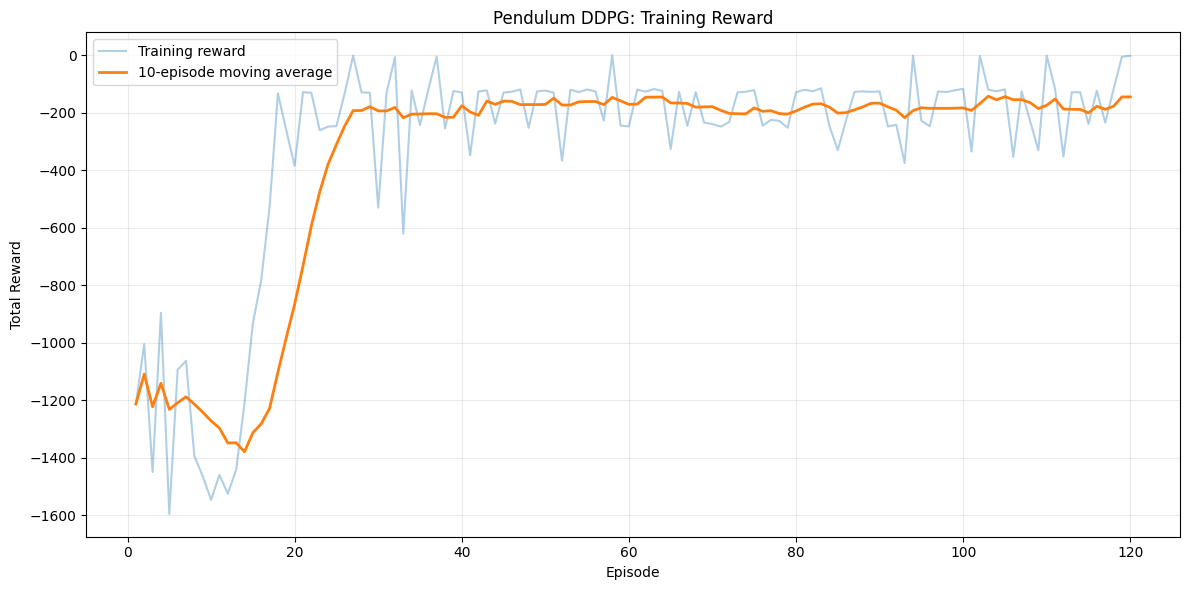

In [15]:
WINDOW = 10

reward_ma = (
    history_df[
        "train_reward"
    ]
    .rolling(
        WINDOW,
        min_periods=1,
    )
    .mean()
)

plt.figure(
    figsize=(12, 6)
)

plt.plot(
    history_df["episode"],
    history_df[
        "train_reward"
    ],
    alpha=0.35,
    label="Training reward",
)

plt.plot(
    history_df["episode"],
    reward_ma,
    linewidth=2,
    label="10-episode moving average",
)

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title(
    "Pendulum DDPG: "
    "Training Reward"
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 30. Deterministic evaluation reward

Evaluation uses the actor without OU noise.

Because Pendulum rewards are non-positive:

$$
\boxed{
\text{higher / less negative reward is better}.
}
$$

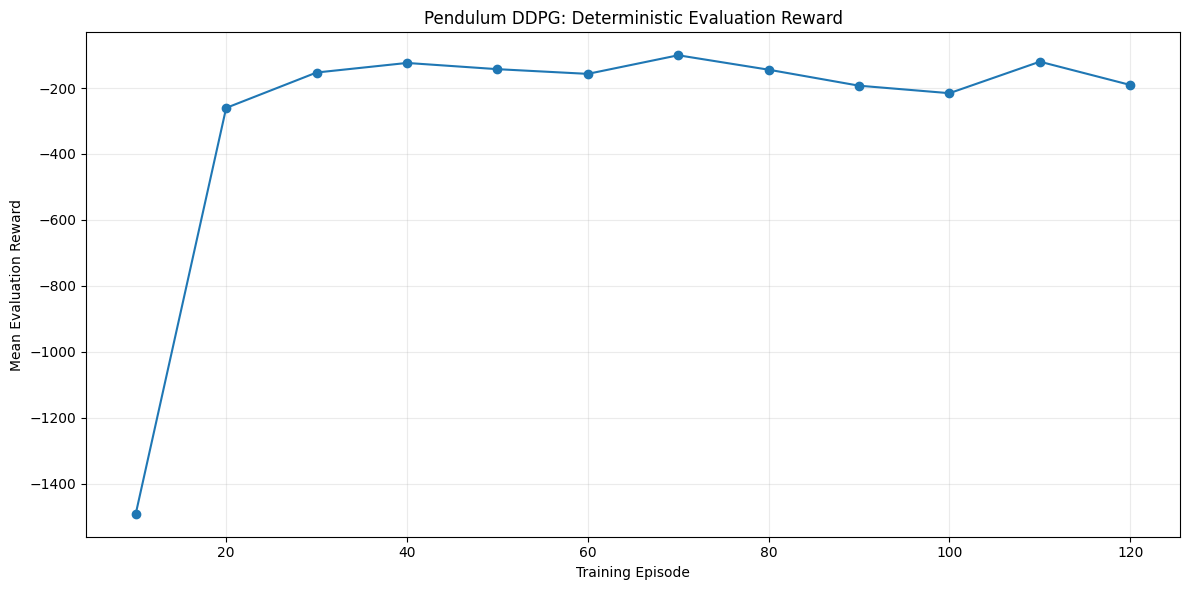

In [16]:
plt.figure(
    figsize=(12, 6)
)

plt.plot(
    evaluation_history_df[
        "episode"
    ],
    evaluation_history_df[
        "mean_reward"
    ],
    marker="o",
)

plt.xlabel(
    "Training Episode"
)
plt.ylabel(
    "Mean Evaluation Reward"
)
plt.title(
    "Pendulum DDPG: "
    "Deterministic Evaluation Reward"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 31. Episode length

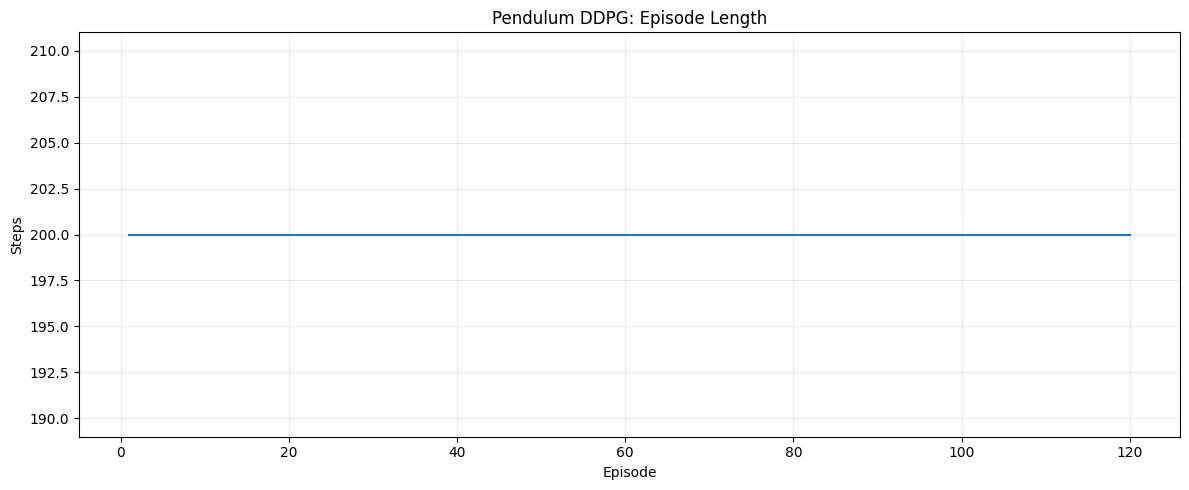

In [17]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    history_df["episode"],
    history_df[
        "episode_length"
    ],
)

plt.xlabel("Episode")
plt.ylabel("Steps")
plt.title(
    "Pendulum DDPG: "
    "Episode Length"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

For the standard environment, episodes are normally truncated after 200 time steps, so this curve is expected to remain near 200 rather than serving as the main performance measure.

## 32. Average critic Q-value

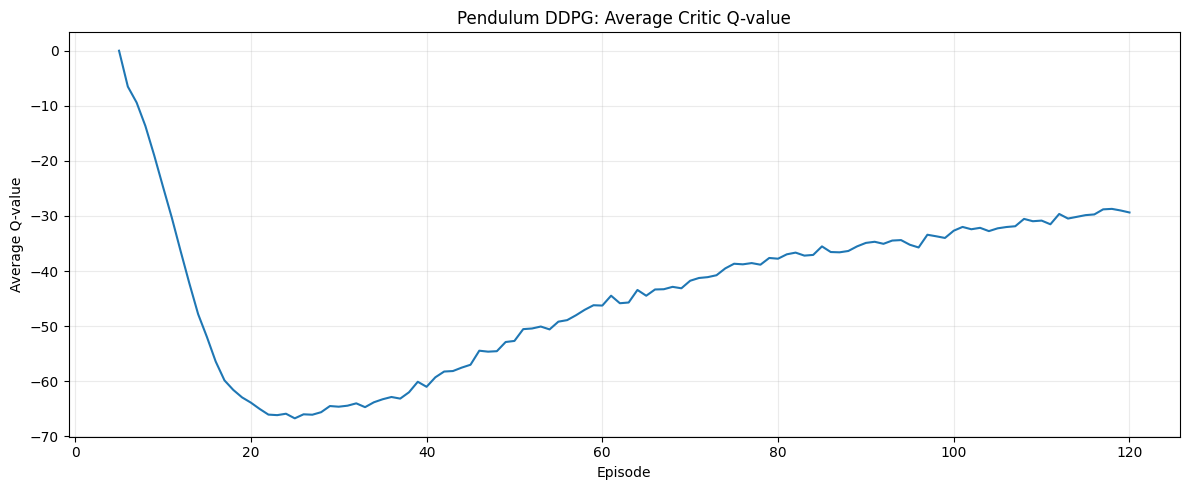

In [18]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    history_df["episode"],
    history_df["average_q"],
)

plt.xlabel("Episode")
plt.ylabel("Average Q-value")
plt.title(
    "Pendulum DDPG: "
    "Average Critic Q-value"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 33. TD error

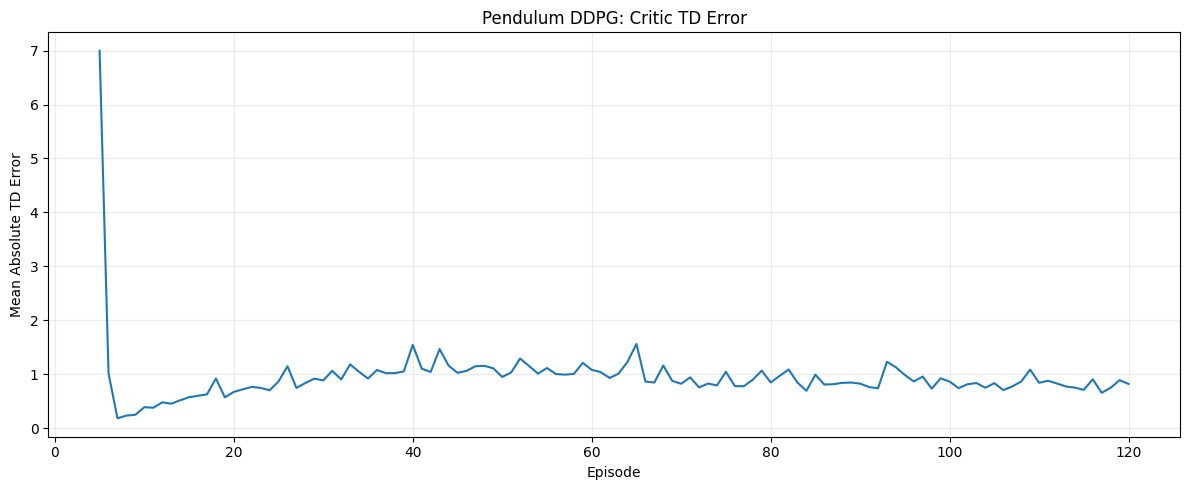

In [19]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    history_df["episode"],
    history_df["td_error"],
)

plt.xlabel("Episode")
plt.ylabel(
    "Mean Absolute TD Error"
)
plt.title(
    "Pendulum DDPG: "
    "Critic TD Error"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 34. Actor loss

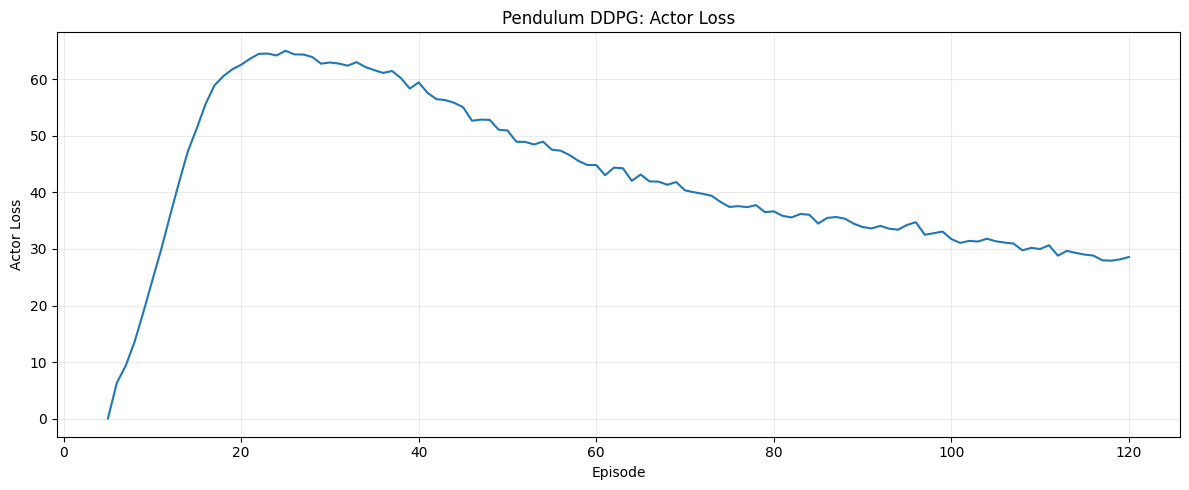

In [20]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    history_df["episode"],
    history_df["actor_loss"],
)

plt.xlabel("Episode")
plt.ylabel("Actor Loss")
plt.title(
    "Pendulum DDPG: "
    "Actor Loss"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 35. Critic loss

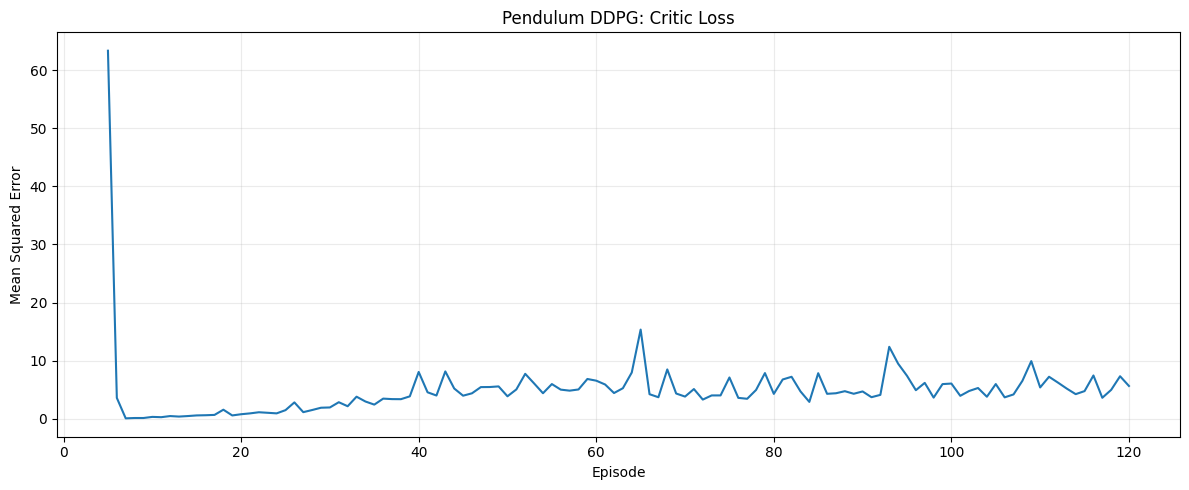

In [21]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    history_df["episode"],
    history_df["critic_loss"],
)

plt.xlabel("Episode")
plt.ylabel("Mean Squared Error")
plt.title(
    "Pendulum DDPG: "
    "Critic Loss"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 36. Mean absolute angle error

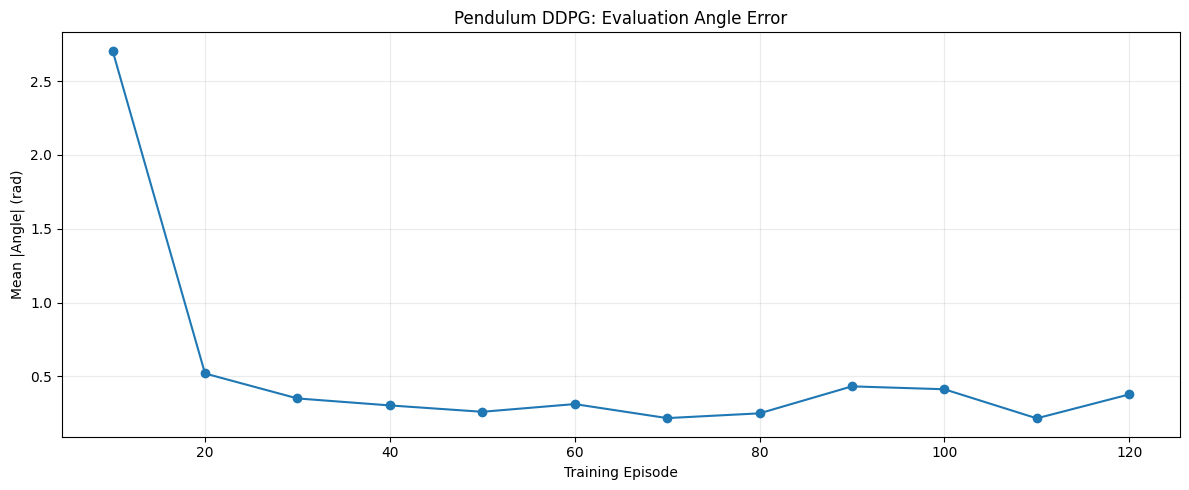

In [22]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    evaluation_history_df[
        "episode"
    ],
    evaluation_history_df[
        "mean_abs_angle"
    ],
    marker="o",
)

plt.xlabel(
    "Training Episode"
)
plt.ylabel(
    "Mean |Angle| (rad)"
)
plt.title(
    "Pendulum DDPG: "
    "Evaluation Angle Error"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 37. Near-upright fraction

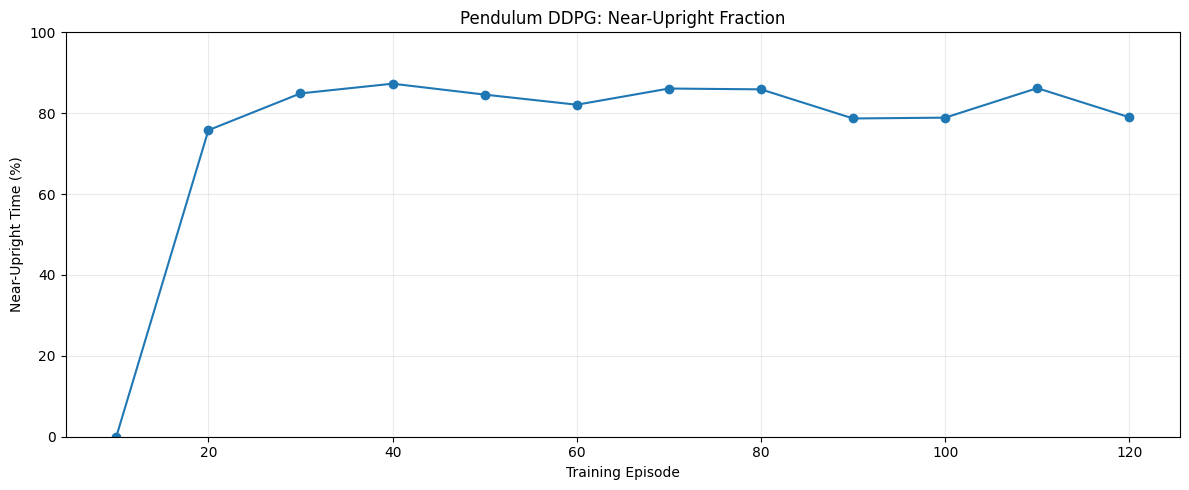

In [23]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    evaluation_history_df[
        "episode"
    ],
    100
    * evaluation_history_df[
        "upright_fraction"
    ],
    marker="o",
)

plt.xlabel(
    "Training Episode"
)
plt.ylabel(
    "Near-Upright Time (%)"
)
plt.title(
    "Pendulum DDPG: "
    "Near-Upright Fraction"
)
plt.ylim(
    0,
    100,
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 38. Evaluation control effort

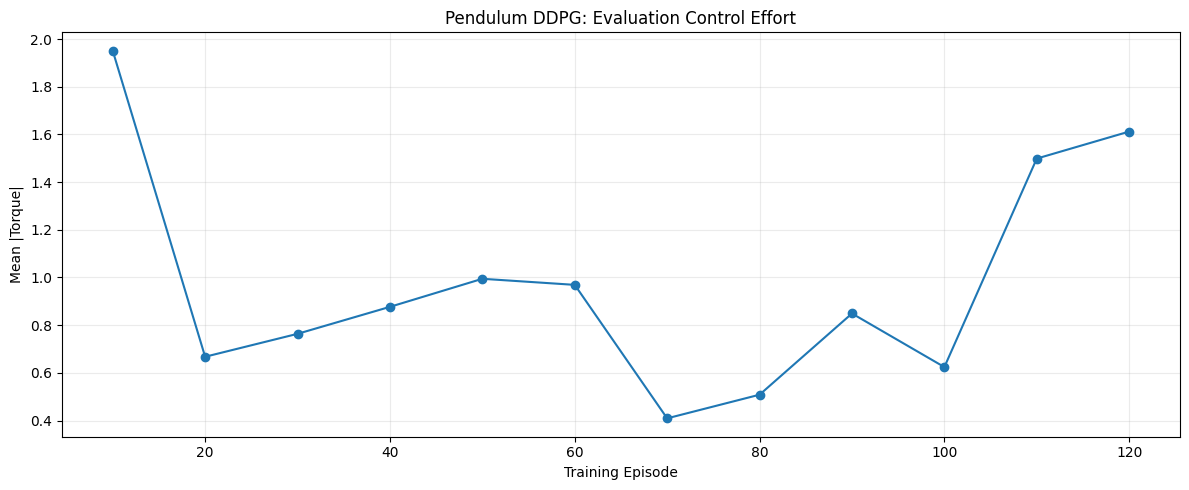

In [24]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    evaluation_history_df[
        "episode"
    ],
    evaluation_history_df[
        "mean_abs_torque"
    ],
    marker="o",
)

plt.xlabel(
    "Training Episode"
)
plt.ylabel(
    "Mean |Torque|"
)
plt.title(
    "Pendulum DDPG: "
    "Evaluation Control Effort"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 39. Random-action baseline

In [25]:
def evaluate_random_policy(
    episodes=20,
    seed=60_000,
):
    env = PendulumEnvironment(
        gym.make(
            "Pendulum-v1"
        )
    )

    records = []

    for episode in range(
        episodes
    ):
        state, info = env.reset(
            seed=seed + episode
        )

        episode_over = False

        total_reward = 0.0
        steps = 0

        abs_angles = []
        abs_velocities = []
        abs_torques = []

        while not episode_over:
            normalized_action = (
                np.random.uniform(
                    -1.0,
                    1.0,
                    size=(1,),
                ).astype(
                    np.float32
                )
            )

            (
                state,
                reward,
                terminated,
                truncated,
                info,
            ) = env.step(
                normalized_action
            )

            episode_over = (
                terminated
                or truncated
            )

            total_reward += reward
            steps += 1

            abs_angles.append(
                abs(
                    info["theta"]
                )
            )

            abs_velocities.append(
                abs(
                    info[
                        "angular_velocity"
                    ]
                )
            )

            abs_torques.append(
                abs(
                    info[
                        "applied_torque"
                    ]
                )
            )

        records.append(
            {
                "episode": episode + 1,
                "reward": total_reward,
                "length": steps,
                "mean_abs_angle": np.mean(
                    abs_angles
                ),
                "mean_abs_angular_velocity": np.mean(
                    abs_velocities
                ),
                "mean_abs_torque": np.mean(
                    abs_torques
                ),
            }
        )

    env.close()

    return pd.DataFrame(
        records
    )


random_eval_df = (
    evaluate_random_policy()
)

display(
    random_eval_df
)

print(
    "Random mean reward:",
    random_eval_df[
        "reward"
    ].mean(),
)

,episode,reward,length,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque
0,1,-841.7063,200,1.1461,4.0099,1.0322
1,2,-1483.5208,200,2.6187,1.9761,1.0476
2,3,-789.7731,200,1.1695,3.6379,1.0066
3,4,-1440.6070,200,2.5448,2.2305,1.0183
4,5,-879.3848,200,1.2909,3.9212,1.0465
5,6,-985.7493,200,1.4295,4.1201,0.9922
6,7,-968.0573,200,1.4273,4.0575,1.0676
7,8,-1217.6936,200,2.1190,3.1931,0.9714
8,9,-1156.1191,200,1.9269,3.6811,0.9892
9,10,-1236.0495,200,2.1512,3.2135,1.0074


Random mean reward: -1134.5323650499781


## 40. Final deterministic evaluation

In [26]:
final_eval_df = evaluate_agent(
    agent,
    episodes=20,
    seed=70_000,
)

display(
    final_eval_df
)

print(
    "Mean reward:",
    final_eval_df[
        "reward"
    ].mean(),
)

print(
    "Reward SD:",
    final_eval_df[
        "reward"
    ].std(),
)

print(
    "Mean |angle|:",
    final_eval_df[
        "mean_abs_angle"
    ].mean(),
)

print(
    "Mean |angular velocity|:",
    final_eval_df[
        "mean_abs_angular_velocity"
    ].mean(),
)

print(
    "Mean |torque|:",
    final_eval_df[
        "mean_abs_torque"
    ].mean(),
)

print(
    "Near-upright fraction:",
    f'{100 * final_eval_df["upright_fraction"].mean():.1f}%',
)

,reward,length,mean_abs_angle,mean_abs_angular_velocity,mean_abs_torque,upright_fraction
0,-124.9505,200,0.2652,0.6063,1.5567,0.850
1,-127.0146,200,0.2590,0.5978,1.5815,0.860
2,-314.4091,200,0.5740,0.8089,1.6258,0.735
3,-5.0454,200,0.0980,0.1480,1.6682,0.920
4,-122.8463,200,0.2561,0.6058,1.5529,0.855
5,-1.7416,200,0.0629,0.1255,1.6695,1.000
6,-123.3323,200,0.2468,0.5829,1.5689,0.870
7,-130.4107,200,0.2769,0.6973,1.6200,0.790
8,-127.3234,200,0.2762,0.6113,1.5600,0.835
9,-3.5072,200,0.0723,0.1642,1.6725,0.970


Mean reward: -121.00913450533167
Reward SD: 89.65064804365346
Mean |angle|: 0.25745464756104053
Mean |angular velocity|: 0.5334913372728624
Mean |torque|: 1.61552420672006
Near-upright fraction: 86.2%


## 41. Random policy versus trained DDPG

In [27]:
comparison_df = pd.DataFrame(
    {
        "Policy": [
            "Random",
            "Trained DDPG",
        ],
        "Mean Reward": [
            random_eval_df[
                "reward"
            ].mean(),
            final_eval_df[
                "reward"
            ].mean(),
        ],
        "Mean |Angle|": [
            random_eval_df[
                "mean_abs_angle"
            ].mean(),
            final_eval_df[
                "mean_abs_angle"
            ].mean(),
        ],
        "Mean |Torque|": [
            random_eval_df[
                "mean_abs_torque"
            ].mean(),
            final_eval_df[
                "mean_abs_torque"
            ].mean(),
        ],
    }
)

display(
    comparison_df
)

,Policy,Mean Reward,Mean |Angle|,Mean |Torque|
0,Random,-1134.5324,1.8272,1.0037
1,Trained DDPG,-121.0091,0.2575,1.6155


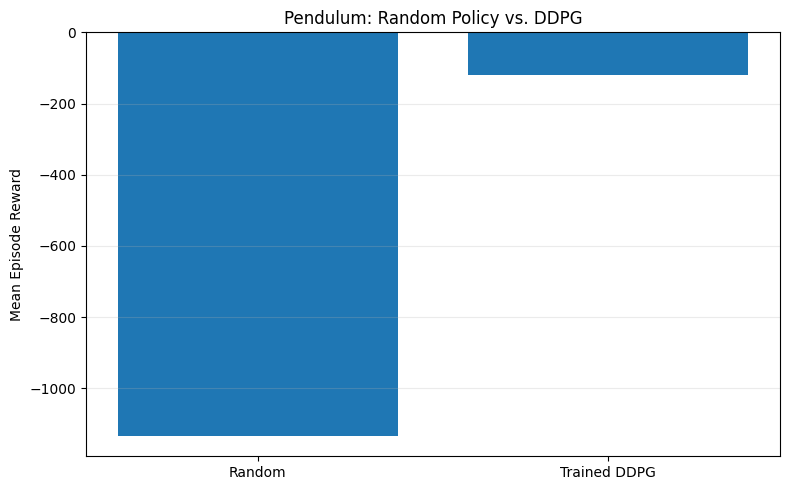

In [28]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    comparison_df["Policy"],
    comparison_df["Mean Reward"],
)

plt.ylabel(
    "Mean Episode Reward"
)

plt.title(
    "Pendulum: "
    "Random Policy vs. DDPG"
)

plt.grid(
    axis="y",
    alpha=0.25,
)

plt.tight_layout()
plt.show()

## 42. Visualize the learned policy over angle and angular velocity

The environment state is represented by

$$
[\cos\theta,\sin\theta,\dot{\theta}],
$$

so we can construct valid observations from an angle-velocity grid.

For every grid point:

$$
a=\mu(
[\cos\theta,\sin\theta,\dot{\theta}]
)
$$

and the physical torque is

$$
\boxed{u=2a}.
$$

The heatmap shows the torque selected by the trained actor.

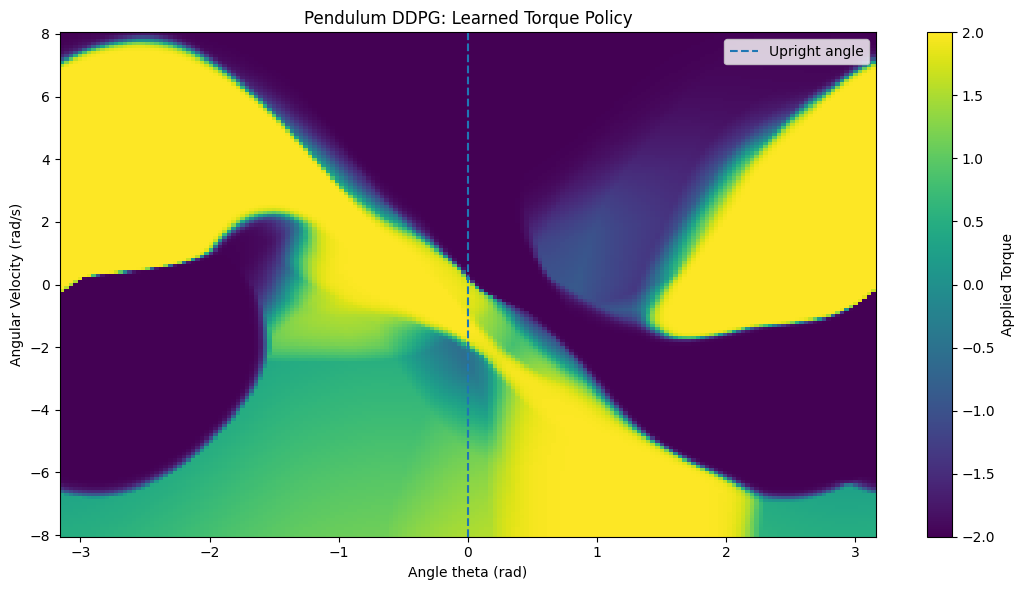

In [29]:
angles = np.linspace(
    -np.pi,
    np.pi,
    181,
)

angular_velocities = (
    np.linspace(
        -8.0,
        8.0,
        161,
    )
)

THETA_GRID, OMEGA_GRID = (
    np.meshgrid(
        angles,
        angular_velocities,
    )
)

policy_states = np.column_stack(
    [
        np.cos(
            THETA_GRID.ravel()
        ),
        np.sin(
            THETA_GRID.ravel()
        ),
        OMEGA_GRID.ravel(),
    ]
).astype(
    np.float32
)

normalized_actions = (
    agent.actor(
        policy_states,
        training=False,
    )
    .numpy()
    .reshape(
        THETA_GRID.shape
    )
)

torque_grid = (
    2.0
    * normalized_actions
)

plt.figure(
    figsize=(11, 6)
)

mesh = plt.pcolormesh(
    THETA_GRID,
    OMEGA_GRID,
    torque_grid,
    shading="auto",
)

plt.colorbar(
    mesh,
    label="Applied Torque",
)

plt.axvline(
    0.0,
    linestyle="--",
    label="Upright angle",
)

plt.xlabel(
    "Angle theta (rad)"
)
plt.ylabel(
    "Angular Velocity (rad/s)"
)
plt.title(
    "Pendulum DDPG: "
    "Learned Torque Policy"
)
plt.legend()
plt.tight_layout()
plt.show()

## 43. Inspect actor and critic at one state

In [30]:
theta = 0.30
angular_velocity = -0.50

inspect_state = np.array(
    [
        np.cos(theta),
        np.sin(theta),
        angular_velocity,
    ],
    dtype=np.float32,
)

state_tensor = (
    tf.convert_to_tensor(
        inspect_state[
            None, :
        ],
        dtype=tf.float32,
    )
)

normalized_action = (
    agent.actor(
        state_tensor,
        training=False,
    ).numpy()[0]
)

torque = (
    2.0
    * normalized_action
)

q_value = (
    agent.critic(
        [
            state_tensor,
            tf.convert_to_tensor(
                normalized_action[
                    None, :
                ],
                dtype=tf.float32,
            ),
        ],
        training=False,
    )
    .numpy()[0, 0]
)

print(
    "State:",
    inspect_state,
)

print(
    "Recovered angle:",
    theta,
)

print(
    "Normalized actor action:",
    normalized_action,
)

print(
    "Applied torque:",
    torque,
)

print(
    "Critic Q-value:",
    q_value,
)

State: [ 0.9553  0.2955 -0.5   ]
Recovered angle: 0.3
Normalized actor action: [-0.9924]
Applied torque: [-1.9849]
Critic Q-value: 2.4526756


## 44. Analyze one complete deterministic trajectory

In [31]:
trajectory_result = (
    evaluate_one_episode(
        agent,
        seed=80_000,
        collect_trajectory=True,
    )
)

trajectory_df = (
    trajectory_result[
        "trajectory"
    ]
)

display(
    trajectory_df.head()
)

print(
    "Episode reward:",
    trajectory_result[
        "reward"
    ],
)

,step,theta,angular_velocity,normalized_action,torque,reward
0,0,0.1272,-0.1773,-1.0000,-2.0000,-0.0226
1,1,0.1085,-0.3734,-0.9709,-1.9419,-0.0231
2,2,0.1058,-0.0541,0.7935,1.5871,-0.0282
3,3,0.0922,-0.2734,-0.9952,-1.9903,-0.0155
4,4,0.0932,0.0203,0.7490,1.4980,-0.0182


Episode reward: -1.8491114778356141


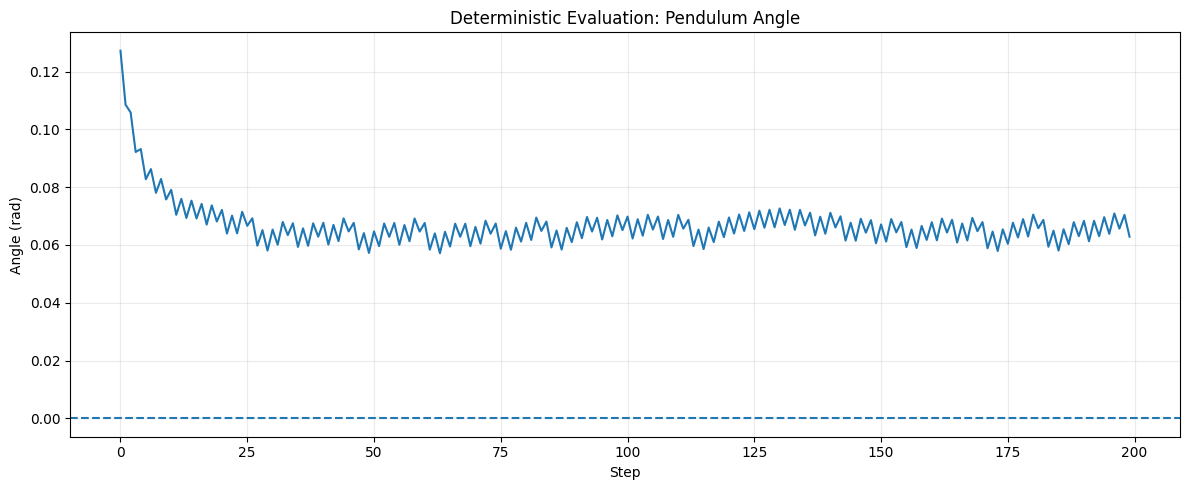

In [32]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    trajectory_df["step"],
    trajectory_df["theta"],
)

plt.axhline(
    0.0,
    linestyle="--",
)

plt.xlabel("Step")
plt.ylabel("Angle (rad)")
plt.title(
    "Deterministic Evaluation: "
    "Pendulum Angle"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

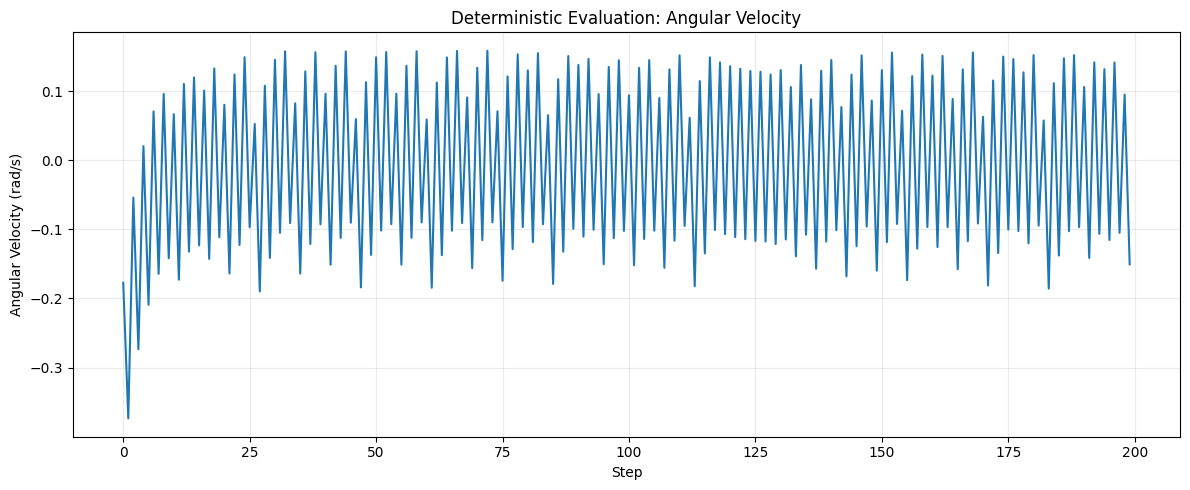

In [33]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    trajectory_df["step"],
    trajectory_df[
        "angular_velocity"
    ],
)

plt.xlabel("Step")
plt.ylabel(
    "Angular Velocity (rad/s)"
)
plt.title(
    "Deterministic Evaluation: "
    "Angular Velocity"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

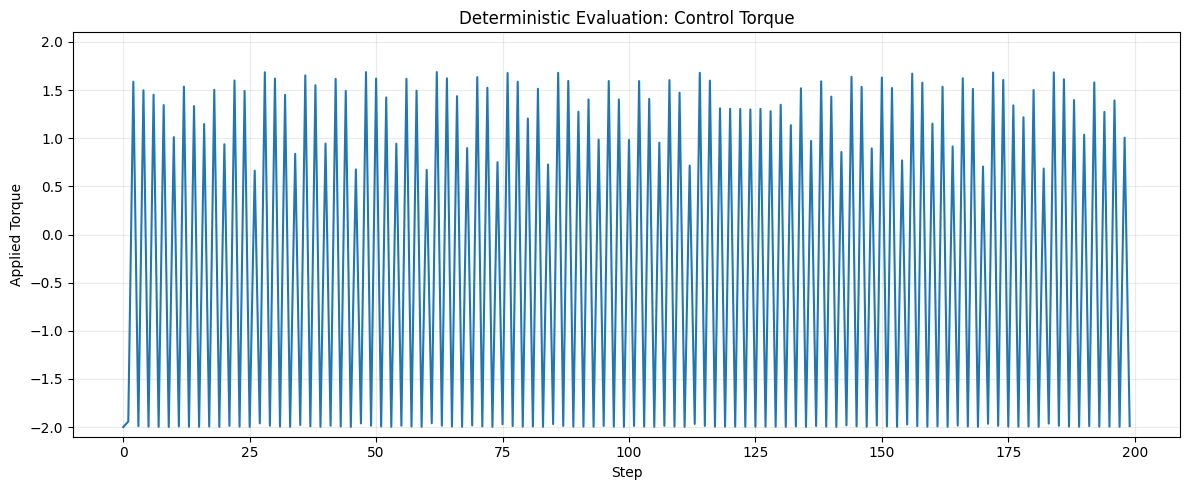

In [34]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    trajectory_df["step"],
    trajectory_df["torque"],
)

plt.xlabel("Step")
plt.ylabel("Applied Torque")
plt.title(
    "Deterministic Evaluation: "
    "Control Torque"
)
plt.ylim(
    -2.1,
    2.1,
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 45. Save and reload the agent

In [35]:
agent.save(
    AGENT_PATH
)

loaded_agent = DDPGAgent(
    actor_lr=0.001,
    critic_lr=0.002,
    gamma=0.99,
    tau=0.005,
    replay_size=100_000,
    min_replay_size=1_000,
)

loaded_agent.load(
    AGENT_PATH
)

print(
    "Restored environment steps:",
    loaded_agent.environment_steps,
)

print(
    "Restored gradient steps:",
    loaded_agent.gradient_steps,
)

Restored environment steps: 24000
Restored gradient steps: 23001


## 46. Record a deterministic evaluation episode

In [36]:
def record_episode(
    agent,
    filename=(
        "pendulum_ddpg.mp4"
    ),
    seed=90_000,
    fps=30,
):
    env = PendulumEnvironment(
        gym.make(
            "Pendulum-v1",
            render_mode="rgb_array",
        )
    )

    state, info = env.reset(
        seed=seed
    )

    frames = [
        env.render()
    ]

    episode_over = False
    total_reward = 0.0
    steps = 0

    while not episode_over:
        action = agent.select_action(
            state,
            training=False,
        )

        (
            state,
            reward,
            terminated,
            truncated,
            info,
        ) = env.step(
            action
        )

        episode_over = (
            terminated
            or truncated
        )

        frames.append(
            env.render()
        )

        total_reward += reward
        steps += 1

    env.close()

    imageio.mimsave(
        filename,
        frames,
        fps=fps,
    )

    print(
        "Video saved:",
        filename,
    )

    print(
        "Reward:",
        total_reward,
    )

    print(
        "Episode length:",
        steps,
    )

    return filename


video_file = record_episode(
    agent
)

display(
    Video(
        video_file,
        embed=True,
    )
)

Video saved: pendulum_ddpg.mp4
Reward: -125.36632780767384
Episode length: 200


## 47. Original code versus this portfolio implementation

| Original component | Portfolio notebook |
|---|---|
| `PendulumEnvironment(GymEnvironment)` | `PendulumEnvironment(gym.Wrapper)` |
| actor output `tanh` | normalized action in `[-1,1]` |
| wrapper `clip(action)*2` | explicit normalized-action-to-torque conversion |
| `get_random_action()` | explicit `OUNoise` |
| `DeepDPG` | `DDPGAgent` |
| `Agent` | `DDPGAgent` |
| hidden replay buffer | explicit `ReplayBuffer` |
| actor network | explicit TensorFlow actor |
| critic network | explicit TensorFlow critic |
| hidden target networks | explicit target actor and critic |
| `tau=0.005` | explicit soft target update |
| `AverageQMetric` | `history["average_q"]` |
| `AbsoluteValueErrorMetric` | `history["td_error"]` |
| `TotalRewardMetric` | training/evaluation reward DataFrames |
| `EpisodeLengthMetric` | `history["episode_length"]` |
| `Plotter` | Matplotlib figures |
| `agent.save()` | `DDPGAgent.save()` |
| `agent.load()` | `DDPGAgent.load()` |
| `LiveEpisodeViewer` | embedded Colab video |
| `VideoEpisodeSaver` | `record_episode()` |

## 48. DDPG algorithm

```text
Input:
    Pendulum environment
    online actor mu(s;theta_mu)
    online critic Q(s,a;theta_Q)
    target actor mu'(s;theta_mu')
    target critic Q'(s,a;theta_Q')
    replay memory D
    OU exploration process
    gamma
    tau

Initialize:
    actor and critic
    target networks as copies
    replay memory
    OU noise state

For each episode:

    Reset environment
    Reset OU noise
    Observe S

    Repeat until episode ends:

        1. Actor generates normalized action

           a = mu(S;theta_mu)

        2. Add OU noise during training

           a_noisy =
               clip(a + X, -1, 1)

        3. Convert to physical torque

           u = 2*a_noisy

        4. Execute u

           Observe R, S',
           terminated, truncated

        5. Store

           (S,a_noisy,R,S',terminated)

           in replay memory

        6. Sample mini-batch

        7. Target actor

           a' = mu'(S')

        8. Target critic

           Q_target =
               Q'(S',a')

        9. Critic target

           Y =
               R
               + gamma(1-terminated)
                 Q_target

       10. Update critic

           minimize:
               mean(Y-Q(S,a))^2

       11. Update actor

           minimize:
               -mean Q(S,mu(S))

       12. Soft-update target actor

           theta_mu' =
               tau*theta_mu
               +(1-tau)*theta_mu'

       13. Soft-update target critic

           theta_Q' =
               tau*theta_Q
               +(1-tau)*theta_Q'

       14. S <- S'

Output:
    trained deterministic actor
```

## 49. Complete DDPG flow

During environment interaction:

$$
\boxed{
[\cos\theta,\sin\theta,\dot{\theta}]
\rightarrow
\mu(S)
\rightarrow
+\text{OU noise}
\rightarrow
a\in[-1,1]
\rightarrow
u=2a
\rightarrow
R,S'
}
$$

During learning:

$$
\boxed{
\mathcal D
\rightarrow
Y
\rightarrow
\text{critic update}
\rightarrow
\text{actor update}
\rightarrow
\text{soft target updates}
}
$$

The key idea is that the actor learns **which continuous torque command to generate**, while the critic learns **how good that action is in the current state**.

## 50. Portfolio interpretation

This project demonstrates:

- continuous-control reinforcement learning,
- deterministic actor-critic learning,
- normalized action design,
- physical action scaling,
- Ornstein-Uhlenbeck exploration,
- experience replay,
- target actor and critic networks,
- soft target updates,
- bootstrapped temporal-difference learning,
- TensorFlow gradient optimization,
- Gymnasium termination-versus-truncation handling,
- deterministic policy evaluation,
- angle and angular-velocity analysis,
- control-effort analysis,
- learned-policy visualization,
- checkpointing,
- and simulation video generation.

For the final portfolio result, the most informative quantities are:

- deterministic evaluation reward,
- mean absolute angle error,
- mean absolute angular velocity,
- mean absolute torque,
- and the custom near-upright fraction.

Remember that Pendulum rewards are negative, so a value closer to zero represents better control.

## References

1. Lillicrap, T. P., Hunt, J. J., Pritzel, A., et al. (2015). **Continuous control with deep reinforcement learning.** arXiv:1509.02971.

2. Gymnasium documentation: **Pendulum**. https://gymnasium.farama.org/environments/classic_control/pendulum/

3. Gymnasium documentation: **Basic Usage**. https://gymnasium.farama.org/introduction/basic_usage/